In [46]:
# this is my notebook for quant 1c project. looking at before and after eu tethered plastic bottle cap regulation

In [47]:
import pandas as pd
import numpy as np
import scipy.stats as sp

In [48]:
austria = pd.read_csv("./data/detailed-summary-austria.csv")
belgium = pd.read_csv("./data/detailed-summary-belgium.csv")
bulgaria = pd.read_csv("./data/detailed-summary-bulgaria.csv")
croatia = pd.read_csv("./data/detailed-summary-croatia.csv")
cyprus = pd.read_csv("./data/detailed-summary-cyprus.csv")
czechia = pd.read_csv("./data/detailed-summary-czechia.csv")
denmark = pd.read_csv("./data/detailed-summary-denmark.csv")
estonia = pd.read_csv("./data/detailed-summary-estonia.csv")
finland = pd.read_csv("./data/detailed-summary-finland.csv")
france = pd.read_csv("./data/detailed-summary-france.csv")
germany = pd.read_csv("./data/detailed-summary-germany.csv")
greece = pd.read_csv("./data/detailed-summary-greece.csv")
hungary = pd.read_csv("./data/detailed-summary-hungary.csv")
ireland = pd.read_csv("./data/detailed-summary-ireland.csv")
italy = pd.read_csv("./data/detailed-summary-italy.csv")
latvia = pd.read_csv("./data/detailed-summary-latvia.csv")
lithuania = pd.read_csv("./data/detailed-summary-lithuania.csv")
malta = pd.read_csv("./data/detailed-summary-malta.csv")
netherlands = pd.read_csv("./data/detailed-summary-netherlands.csv")
poland = pd.read_csv("./data/detailed-summary-poland.csv")
portugal = pd.read_csv("./data/detailed-summary-portugal.csv")
romania = pd.read_csv("./data/detailed-summary-romania.csv")
slovakia = pd.read_csv("./data/detailed-summary-slovakia.csv")
slovenia = pd.read_csv("./data/detailed-summary-slovenia.csv")
spain = pd.read_csv("./data/detailed-summary-spain.csv")
sweden = pd.read_csv("./data/detailed-summary-sweden.csv")

df = pd.concat([
    austria,
    belgium,
    bulgaria,
    croatia,
    cyprus,
    czechia,
    denmark,
    estonia,
    finland,
    france,
    germany,
    greece,
    hungary,
    ireland,
    italy,
    latvia,
    lithuania,
    malta,
    netherlands,
    poland,
    portugal,
    romania,
    slovakia,
    slovenia,
    spain,
    sweden
], ignore_index=True)

df

,Cleanup ID,Zone,State,Country,Latitude,Longitude,Cleanup Type,Environment,Cleanup Date,Group Name,...,Other plastic/foam packaging,Tobacco packaging/wrap,Cigar tips,Cigarette lighters,Fireworks,"Other tobacco (packaging, lighter, etc.)",Foam pieces,Glass pieces,Plastic pieces,Total Items Collected
0,282231,"Schwaz District, Austria","Tyrol, Austria",Austria,47.166778,11.865272,land,NaN,2023-05-31,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0
1,282232,"Schwaz District, Austria","Tyrol, Austria",Austria,47.166707,11.865285,land,NaN,2023-05-31,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0
2,282354,"Vienna, Austria","Vienna, Austria",Austria,48.194622,16.446747,land,NaN,2023-05-29,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0
3,305521,"Vienna, Austria","Vienna, Austria",Austria,48.215486,16.400839,land,inland,2023-09-16,AKTI Prater Park,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Totals:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5946,364768,"Ängelholm Municipality, Sweden","Skåne County, Sweden",Sweden,56.283300,12.733300,land,saltwater,2024-09-21,Vejbystrand,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
5947,364769,"Österåker Municipality, Sweden","Stockholm County, Sweden",Sweden,59.456700,18.358951,land,saltwater,2024-09-21,Brevik,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
5948,364770,"Varberg Municipality, Sweden","Halland County, Sweden",Sweden,57.100000,12.250000,land,saltwater,2024-09-21,Kustomrde frn Taparken till Turisttoaletterna,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
5949,393537,"Robertsfors Municipality, Sweden","Västerbotten County, Sweden",Sweden,63.991349,20.872819,land,saltwater,2025-09-20,Clean Sweden,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
df = df.drop(columns=[
    'Zone', 'State', 'Latitude', 'Longitude',
    'Cleanup Type', 'Environment', 'Group Name',
    'Adults', 'Children',
    'Distance mi', 'Area mi', '# of bags',
    'Grocery bags (plastic)', 'Other bags (plastic)',
    'Beverage bottles (glass)', 'Beverage cans',
    'Beverage sachets/pouches', 'Bottle caps (metal)',
    'Cigarette butts', 'Cups, Plates (foam)',
    'Cups, Plates (paper)', 'Cups, Plates (plastic)',
    'Food containers (foam)', 'Food containers (plastic)',
    'Food wrappers (candy, chips, etc.)',
    'Lids (plastic)', 'Straws/stirrers (plastic)',
    'Utensils (plastic)',
    'Lines, nets, traps, ropes, etc.', 'Foam dock pieces',
    'Appliances (refrigerators, washers, etc.)',
    'Construction materials', 'Tires', '6-Pack holders',
    'Foam packaging',
    'Other plastic bottles (oil, bleach, etc.)',
    'Strapping bands', 'Balloons', 'Clothing',
    'E-cigarettes',
    'Electronic waste (phones, batteries)',
    'Footwear (shoes/slippers)', 'Paper bags',
    'Tobacco products (lighters, cigar tips, wrap)',
    'Toys', 'Other plastic waste',
    'Other waste (metal, paper, etc.)',
    'Condoms', 'Cotton bud sticks (swabs)',
    'Diapers', 'Gloves & masks (PPE)',
    'Syringes', 'Tampons & applicators',
    'Plastic/foam pieces',
    'Fishing buoys, pots & traps',
    'Fishing net & pieces',
    'Fishing line (1 yard/meter = 1 piece)',
    'Rope (1 yard/meter = 1 piece)',
    'Other plastic/foam packaging',
    'Tobacco packaging/wrap', 'Cigar tips',
    'Cigarette lighters', 'Fireworks',
    'Other tobacco (packaging, lighter, etc.)',
    'Foam pieces', 'Glass pieces', 'Plastic pieces'
])

In [50]:
df

,Cleanup ID,Country,Cleanup Date,People,Pounds,Beverage bottles (plastic),Bottle caps (plastic),Total Items Collected
0,282231,Austria,2023-05-31,1.0,0.24,3.0,2.0,16.0
1,282232,Austria,2023-05-31,1.0,0.37,NaN,NaN,5.0
2,282354,Austria,2023-05-29,1.0,0.21,NaN,NaN,13.0
3,305521,Austria,2023-09-16,2.0,3.31,NaN,NaN,NaN
4,Totals:,NaN,NaN,NaN,NaN,3.0,2.0,NaN
...,...,...,...,...,...,...,...,...
5946,364768,Sweden,2024-09-21,28.0,120.00,NaN,NaN,2.0
5947,364769,Sweden,2024-09-21,21.0,120.00,NaN,NaN,2.0
5948,364770,Sweden,2024-09-21,28.0,90.00,NaN,NaN,1.0
5949,393537,Sweden,2025-09-20,2962.0,"17,920.00",NaN,NaN,NaN


In [51]:
#get rid of totals because will do manually with specific time frames
# also getting rid of rows with 0 if there is any because dividing by 0 is bad. 
df = df[df["Cleanup ID"] != "Totals:"]
df = df[df["Beverage bottles (plastic)"] != 0]
df = df[df["Bottle caps (plastic)"] != 0]

df

,Cleanup ID,Country,Cleanup Date,People,Pounds,Beverage bottles (plastic),Bottle caps (plastic),Total Items Collected
0,282231,Austria,2023-05-31,1.0,0.24,3.0,2.0,16.0
1,282232,Austria,2023-05-31,1.0,0.37,NaN,NaN,5.0
2,282354,Austria,2023-05-29,1.0,0.21,NaN,NaN,13.0
3,305521,Austria,2023-09-16,2.0,3.31,NaN,NaN,NaN
5,162682,Belgium,2021-03-23,1.0,2.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
5945,364767,Sweden,2024-09-21,27.0,80.00,NaN,NaN,2.0
5946,364768,Sweden,2024-09-21,28.0,120.00,NaN,NaN,2.0
5947,364769,Sweden,2024-09-21,21.0,120.00,NaN,NaN,2.0
5948,364770,Sweden,2024-09-21,28.0,90.00,NaN,NaN,1.0


In [52]:
clean_df = df.copy()

In [53]:
clean_df['cap_bottle_ratio'] = (clean_df['Bottle caps (plastic)'] / clean_df['Beverage bottles (plastic)'])
clean_df #need to add this column for later

,Cleanup ID,Country,Cleanup Date,People,Pounds,Beverage bottles (plastic),Bottle caps (plastic),Total Items Collected,cap_bottle_ratio
0,282231,Austria,2023-05-31,1.0,0.24,3.0,2.0,16.0,0.666667
1,282232,Austria,2023-05-31,1.0,0.37,NaN,NaN,5.0,NaN
2,282354,Austria,2023-05-29,1.0,0.21,NaN,NaN,13.0,NaN
3,305521,Austria,2023-09-16,2.0,3.31,NaN,NaN,NaN,NaN
5,162682,Belgium,2021-03-23,1.0,2.00,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
5945,364767,Sweden,2024-09-21,27.0,80.00,NaN,NaN,2.0,NaN
5946,364768,Sweden,2024-09-21,28.0,120.00,NaN,NaN,2.0,NaN
5947,364769,Sweden,2024-09-21,21.0,120.00,NaN,NaN,2.0,NaN
5948,364770,Sweden,2024-09-21,28.0,90.00,NaN,NaN,1.0,NaN


In [54]:
#now to seperate timelines 

In [55]:
clean_df['Cleanup Date'] = pd.to_datetime(clean_df['Cleanup Date'])

before = clean_df[(clean_df['Cleanup Date'] >= '2021-01-01') & (clean_df['Cleanup Date'] < '2022-12-31')]
during = clean_df[(clean_df['Cleanup Date'] >= '2023-01-01') & (clean_df['Cleanup Date'] < '2024-06-01')]
after = clean_df[(clean_df['Cleanup Date'] >= '2024-07-01') & (clean_df['Cleanup Date'] <= '2026-05-15')]

In [56]:
before.describe()

,Cleanup Date,People,Beverage bottles (plastic),Bottle caps (plastic),Total Items Collected,cap_bottle_ratio
count,2808,2803.000000,1393.000000,1333.000000,2108.000000,1112.000000
mean,2022-01-08 23:01:01.538461696,17.398145,22.522613,35.561140,510.131404,3.500580
min,2021-01-01 00:00:00,1.000000,1.000000,1.000000,1.000000,0.010526
25%,2021-08-26 00:00:00,1.000000,2.000000,3.000000,32.750000,0.623922
50%,2021-10-16 00:00:00,3.000000,6.000000,10.000000,155.000000,1.333333
75%,2022-08-31 00:00:00,12.000000,20.000000,28.000000,568.500000,2.851687
max,2022-12-29 00:00:00,9060.000000,1250.000000,1500.000000,26949.000000,145.000000
std,NaN,176.069125,60.113384,102.781863,1183.719496,8.954448


In [57]:
during.describe()

,Cleanup Date,People,Beverage bottles (plastic),Bottle caps (plastic),Total Items Collected,cap_bottle_ratio
count,1745,1745.000000,756.000000,752.000000,1136.000000,623.000000
mean,2023-09-03 19:12:00.000000256,13.793696,28.132275,32.819149,898.250880,4.606363
min,2023-01-01 00:00:00,1.000000,1.000000,1.000000,1.000000,0.004657
25%,2023-06-05 00:00:00,2.000000,3.000000,4.000000,54.000000,0.533889
50%,2023-09-16 00:00:00,6.000000,8.000000,12.000000,241.500000,1.500000
75%,2023-10-21 00:00:00,16.000000,23.000000,31.000000,960.000000,4.000000
max,2024-05-31 00:00:00,1000.000000,910.000000,694.000000,72913.000000,137.500000
std,NaN,33.302424,77.422337,69.404691,2721.043058,10.902940


In [58]:
after.describe()

,Cleanup Date,People,Beverage bottles (plastic),Bottle caps (plastic),Total Items Collected,cap_bottle_ratio
count,1282,1282.000000,655.000000,639.000000,1075.000000,517.000000
mean,2025-03-07 08:47:55.507020288,42.935257,19.325191,25.453834,741.766512,3.320518
min,2024-07-01 00:00:00,1.000000,1.000000,1.000000,1.000000,0.008333
25%,2024-09-20 00:00:00,2.000000,2.000000,3.000000,40.500000,0.571429
50%,2024-11-16 00:00:00,5.000000,5.000000,7.000000,162.000000,1.217650
75%,2025-09-01 00:00:00,14.000000,13.000000,17.000000,453.500000,3.083333
max,2026-05-15 00:00:00,16292.000000,1847.000000,2249.000000,193268.000000,154.000000
std,NaN,487.312890,94.714295,102.333774,6031.034300,8.633378


In [59]:
before['Beverage bottles (plastic)'].sum()

np.float64(31374.0)

In [60]:
during['Beverage bottles (plastic)'].sum()

np.float64(21268.0)

In [61]:
after['Beverage bottles (plastic)'].sum()

np.float64(12658.0)

In [62]:
before['Bottle caps (plastic)'].sum()

np.float64(47403.0)

In [63]:
during['Bottle caps (plastic)'].sum()

np.float64(24680.0)

In [64]:
after['Bottle caps (plastic)'].sum()

np.float64(16265.0)

In [65]:
# bottle to cap ratio
before_ratio = before['Bottle caps (plastic)'].sum() / before['Beverage bottles (plastic)'].sum()
before_ratio

np.float64(1.5109007458405048)

In [66]:
during_ratio = during['Bottle caps (plastic)'].sum() / during['Beverage bottles (plastic)'].sum()
during_ratio

np.float64(1.1604288132405491)

In [67]:
after_ratio = after['Bottle caps (plastic)'].sum() / after['Beverage bottles (plastic)'].sum()
after_ratio

np.float64(1.2849581292463264)

In [68]:
#cpr_before = before['cap_bottle_ratio'].mean()
#cpr_before

In [69]:
#cpr_after = after['cap_bottle_ratio'].mean()
#cpr_after

In [70]:
#ttest = sp.ttest_ind(cpr_before, cpr_after)
#ttest

In [71]:
#ttest = sp.ttest_ind(before_ratio, after_ratio)
#ttest

In [72]:
cpr_before = pd.DataFrame(before["cap_bottle_ratio"])
cpr_after = pd.DataFrame(after["cap_bottle_ratio"])
#cpr is cap bottle ratio

In [73]:
cpr_before.describe()

,cap_bottle_ratio
count,1112.000000
mean,3.500580
std,8.954448
min,0.010526
25%,0.623922
50%,1.333333
75%,2.851687
max,145.000000


In [74]:
#ttest = sp.ttest_ind(before['cap_bottle_ratio'], after['cap_bottle_ratio'])
#ttest

In [75]:
#apparently cant have nans in the group

In [76]:
clean_before = before['cap_bottle_ratio'].dropna()
clean_after = after['cap_bottle_ratio'].dropna()

In [77]:
ttest = sp.ttest_ind(clean_before, clean_after)
ttest

TtestResult(statistic=np.float64(0.3820552979761666), pvalue=np.float64(0.7024702431940862), df=np.float64(1627.0))

In [78]:
#success i think. that p value looks terrible

In [79]:
#lollipop visual for difference in eu per country - didnt know how to do that
import seaborn as sns
import matplotlib.pyplot as plt

In [80]:
#have to standardise the time time periods of the ooverall clean up 

In [81]:
clean_df['Cleanup Date'] = pd.to_datetime(clean_df['Cleanup Date'])

before_1yr = clean_df[(clean_df['Cleanup Date'] >= '2022-01-01') & (clean_df['Cleanup Date'] <= '2022-12-31')]
during_1yr = clean_df[(clean_df['Cleanup Date'] >= '2023-01-01') & (clean_df['Cleanup Date'] <= '2023-12-31')]
twentyfour = clean_df[(clean_df['Cleanup Date'] >= '2024-01-01') & (clean_df['Cleanup Date'] <= '2024-12-31')]
after_1yr  = clean_df[(clean_df['Cleanup Date'] >= '2025-01-01') & (clean_df['Cleanup Date'] <= '2025-12-31')]

In [82]:
twentyfour['Beverage bottles (plastic)'].sum()

np.float64(12412.0)

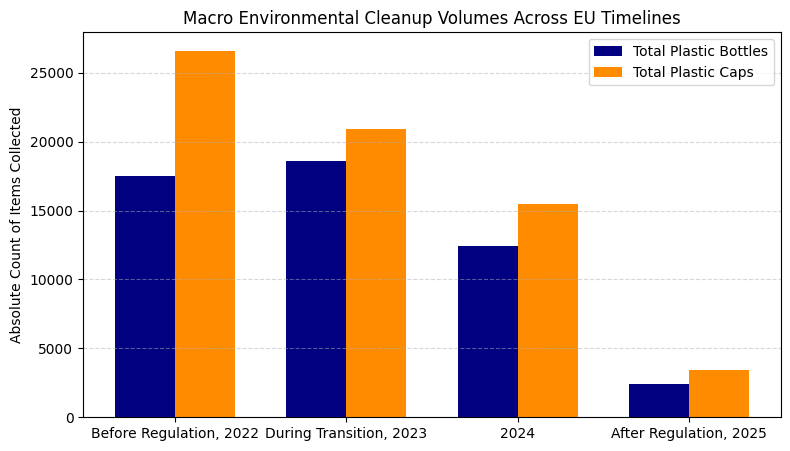

In [83]:
categories = ['Before Regulation, 2022', 'During Transition, 2023', '2024', 'After Regulation, 2025']
bottles_sum = [before_1yr['Beverage bottles (plastic)'].sum(), during_1yr['Beverage bottles (plastic)'].sum(), 12412, after_1yr['Beverage bottles (plastic)'].sum()]
caps_sum = [before_1yr['Bottle caps (plastic)'].sum(),during_1yr['Bottle caps (plastic)'].sum(), 15470, after_1yr['Bottle caps (plastic)'].sum()]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, bottles_sum, width, label='Total Plastic Bottles', color='navy')
ax.bar(x + width/2, caps_sum, width, label='Total Plastic Caps', color='darkorange')

ax.set_ylabel('Absolute Count of Items Collected')
ax.set_title('Macro Environmental Cleanup Volumes Across EU Timelines')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

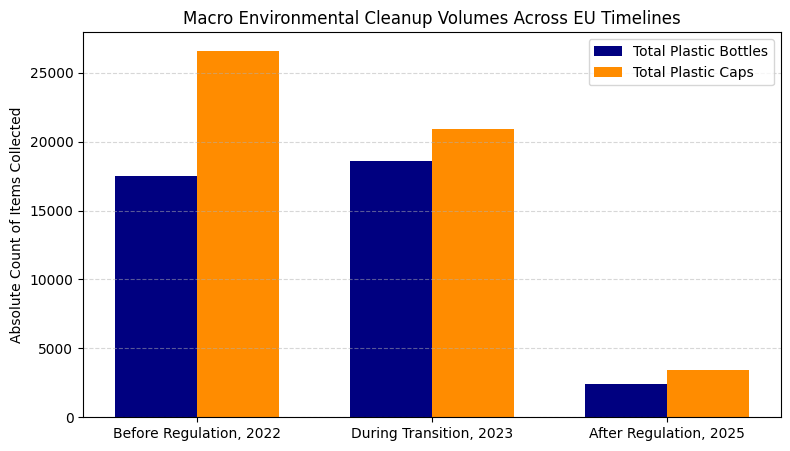

In [84]:
categories = ['Before Regulation, 2022', 'During Transition, 2023', 'After Regulation, 2025']
bottles_sum = [before_1yr['Beverage bottles (plastic)'].sum(), during_1yr['Beverage bottles (plastic)'].sum(), after_1yr['Beverage bottles (plastic)'].sum()]
caps_sum = [before_1yr['Bottle caps (plastic)'].sum(),during_1yr['Bottle caps (plastic)'].sum(), after_1yr['Bottle caps (plastic)'].sum()]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, bottles_sum, width, label='Total Plastic Bottles', color='navy')
ax.bar(x + width/2, caps_sum, width, label='Total Plastic Caps', color='darkorange')

ax.set_ylabel('Absolute Count of Items Collected')
ax.set_title('Macro Environmental Cleanup Volumes Across EU Timelines')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

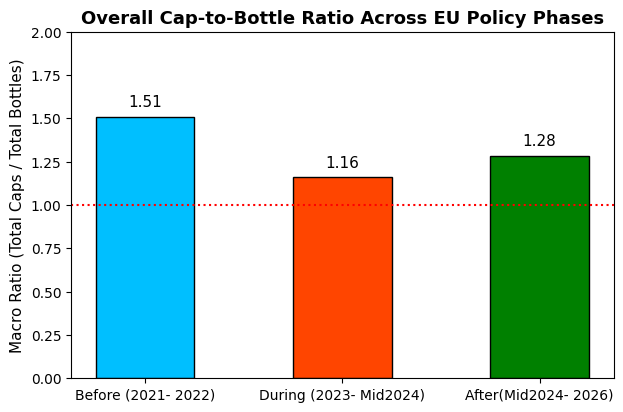

In [85]:
categories = ['Before (2021- 2022)', 'During (2023- Mid2024)', 'After(Mid2024- 2026)']
macro_ratios = [before_ratio, during_ratio, after_ratio]

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(categories, macro_ratios, color=['deepskyblue', 'orangered', 'green'], edgecolor='black', width=0.5)

ax.set_title('Overall Cap-to-Bottle Ratio Across EU Policy Phases', fontsize=13, fontweight='bold')
ax.set_ylabel('Macro Ratio (Total Caps / Total Bottles)', fontsize=11)
ax.set_ylim(0, 2.0)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), 
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11)

ax.axhline(1.0, color='red', linestyle=':')

plt.show()